## Analyzing Wave Statistics from ADCP Altimeter Data

The following notebook illustrates how to process and compute wave statistics from acoustic Doppler current profilers (ADCPs) with the ability to measure waves (Nortek AWAC, Signature and RDI SentinelV). This example assumes the user is familiar with the basic workflow for processing ADCP data.

Firstly, the ADCP must have been configured in wave measurement mode for deployment. This mode is only available for ADCPs with a vertically-oriented center transducer, which is used to located the water surface. The other four beams are utilized to measure water velocity at and around the water surface in order to track wave orbitals. The following basic workflow runs through the following:

1. Import Data
2. Review and QC altimeter measurements
3. Create energy spectra from surface height
4. Compute wave height and period
5. Review and QC surface velocity measurements
6. Use "SUV" method to compute wave direction and spread

We'll begin analysis by importing the DOLfYN and wave modules from MHKiT. 

In [1]:
from mhkit import dolfyn
from mhkit import wave

### 1. Import Raw Datafile

We'll start by using DOLfYN to read the binary file into python. This particular file is a clip from a Nortek Signature250 deployed at PacWave South, Oregon. In this case, the instrument was configured on a duty cycle to measure both waves and water velocity. Because two different profiling methods were used, DOLfYN will output two individual datasets.

In this notebook, we'll focus on the waves dataset. A workflow for the water velocity dataset, which is the traditional ADCP measurement scheme, can be found in the ADCP example notebook.

In [2]:
ds_waves, ds_avg = dolfyn.read("data/dolfyn/Sig250_PacWave.ad2cp")

C:\Users\mcve343\MHKiT-Python\mhkit\dolfyn\io\nortek2_lib.py:304: UserWarning: Dual Profile detected... Two datasets will be returned.
  warnings.warn(msg)


Reading file data/dolfyn/Sig250_PacWave.ad2cp ...


If we print the dataset, we can see all of the data variables that the ADCP collects for wave measurements. ADCPs measure basic wave information by using an altimeter pulse to detect where the surface is. 

The ADCP first (and periodically thereafter) sends out a series of sample pulses to calibrate the altimeter. These are saved in the dataset with the tag "_altraw". The ADCP then sends out altimeter pings at the user-defined sampling rate, which are saved in the dataset with the "_alt" tag.

The altimeter pings are interpreted by the instrument using two different algorithms, called "acoustic surface tracking" (AST) and the "leading edge" (LE) method. These variables have either an "ast_" or "le_" prefix to their names. AST is typically used for measuring the air-water interface, while LE is better for detecting boundaries between water and other dense mediums, such as sea ice or seafloor.

In [3]:
ds_waves

<xarray.Dataset> Size: 11MB
Dimensions:                 (time: 18073, time_altraw: 35, range: 13, beam: 4,
                             dir: 4, dirIMU: 3, n_altraw: 2583, x1: 4, x2: 4,
                             earth: 3, inst: 3)
Coordinates:
  * time                    (time) datetime64[ns] 145kB 2024-10-22T19:29:36.3...
  * time_altraw             (time_altraw) datetime64[ns] 280B 2024-10-22T19:2...
  * range                   (range) float64 104B 38.7 42.2 45.7 ... 77.2 80.7
  * beam                    (beam) int32 16B 1 2 3 4
  * dir                     (dir) int32 16B 1 2 3 4
  * dirIMU                  (dirIMU) <U1 12B 'X' 'Y' 'Z'
  * x1                      (x1) int32 16B 1 2 3 4
  * x2                      (x2) int32 16B 1 2 3 4
  * earth                   (earth) <U1 12B 'E' 'N' 'U'
  * inst                    (inst) <U1 12B 'X' 'Y' 'Z'
Dimensions without coordinates: n_altraw
Data variables: (12/39)
    c_sound                 (time) float32 72kB 1.503e+03 ... 1.485e+03
    temp                    (time) float32 72kB 13.93 13.92 13.92 ... 8.23 8.23
    pressure                (time) float32 72kB 0.768 0.765 ... 74.71 74.71
    heading                 (time) float32 72kB 216.1 215.8 ... 212.7 212.9
    pitch                   (time) float32 72kB -27.59 -28.03 ... 2.21 2.22
    roll                    (time) float32 72kB 73.04 71.68 67.74 ... -0.36 -0.4
    ...                      ...
    low_volt_skip           (time) uint8 18kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    active_config           (time) uint8 18kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    telemetry_data          (time) uint8 18kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    boost_running           (time) uint8 18kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    beam2inst_orientmat     (x1, x2) float32 64B 1.462 0.0 -1.462 ... 0.0 0.532
    orientmat               (earth, inst, time) float32 651kB -0.5221 ... 0.9992
Attributes: (12/39)
    filehead_config:       {"CLOCKSTR": {"TIME": "\"2024-10-22 19:29:32\""}, ...
    inst_model:            Signature250
    inst_make:             Nortek
    inst_type:             ADCP
    burst_config:          {"press_valid": true, "temp_valid": true, "compass...
    n_cells:               13
    ...                    ...
    rotate_vars:           ['vel', 'accel', 'mag']
    coord_sys:             beam
    fs:                    1
    bandwidth:             "BROAD"
    has_imu:               0
    beam_angle:            20

### 2. Review and QC Altimeter Measurements

Now that we've read in our data, our next step is to check the quality of the water surface measurements. We can do this by plotting the 'pressure_alt', 'ast_dist_alt' and 'le_dist_alt' variables.

Since this dataset is a clip of the very start of a deployment, we can see that the instrument began recording before it was on the seafloor. Our next move will be to trim those measurements off.

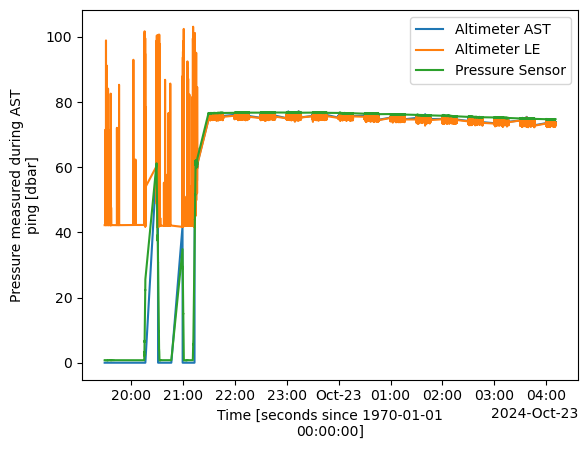

In [4]:
import matplotlib.pyplot as plt

ds_waves["ast_dist_alt"].plot(label="Altimeter AST")
ds_waves["le_dist_alt"].plot(label="Altimeter LE")
ds_waves["pressure_alt"].plot(label="Pressure Sensor")
plt.legend()

Text(0, 0.5, 'Range [m]')

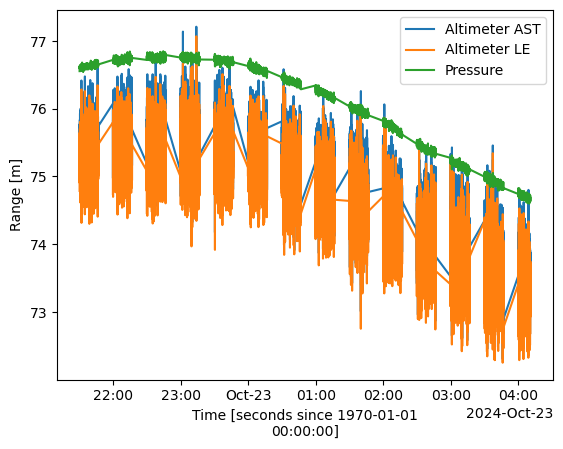

In [5]:
import numpy as np

# Trim time to after Oct 22, 2024 21:30
time_slc = slice(np.datetime64("2024-10-22T21:30"), None)
# Trim time for every time variable
ds_waves = ds_waves.sel(time=time_slc, time_altraw=time_slc)

ds_waves["ast_dist_alt"].plot(label="Altimeter AST")
ds_waves["le_dist_alt"].plot(label="Altimeter LE")
ds_waves["pressure_alt"].plot(label="Pressure")
plt.legend()
plt.ylabel("Range [m]")

In the plot above we can see a couple things. One, our altimeter is operating in pulses of approximately 20 minutes, and two, our pressure sensor appears like it was not zeroed perfectly before deployment. This can be due to multiple reasons, and it is always a good thing to verify in post. We can calculate water depth from the pressure reading next and verify it against the altimeter measurements.

To do so, we can check that the pressure sensor was zeroed properly by looking at the pressure data immediately before deployment, where it is reading ~0.7 dBar. Adjusting the pressure measurement by -0.7 dBar appears to then correct the depth measurement when comparing it to the altimeter readings.

Text(0, 0.5, 'Range [m]')

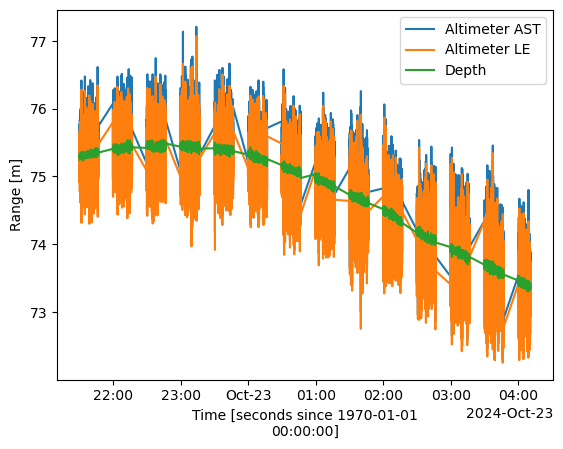

In [6]:
ds_waves["pressure"] -= 0.7  # Adjust pressure sensor by 0.7 dBar

# Calculate water depth
dolfyn.adp.clean.water_depth_from_pressure(ds_waves, salinity=35)

ds_waves["ast_dist_alt"].plot(label="Altimeter AST")
ds_waves["le_dist_alt"].plot(label="Altimeter LE")
ds_waves["depth"].plot(label="Depth")
plt.legend()
plt.ylabel("Range [m]")



The ADCP records a quality indicator that corresponds with each altimeter measurement algorithm, ranging from 0 to 100. These indicators are saved in the dataset as variables called "ast_quality_alt" and "le_quality_alt". We can use these variables to remove poor altimeter measurements.

If values are removed, it is worthwhile to replace these values using the method of your choice. The FFT algorithm is unable to handle NaNs, and any windows that contain one with result in a spectrum filled with NaN.

In [7]:
# Remove datapoints where quality is below 40
ds_waves["ast_dist_alt"] = ds_waves["ast_dist_alt"].where(ds_waves["ast_quality_alt"] > 40)
ds_waves["le_dist_alt"] = ds_waves["le_dist_alt"].where(ds_waves["le_quality_alt"] > 40)

# Interpolate gaps smaller than 5 seconds
ds_waves["ast_dist_alt"] = ds_waves["ast_dist_alt"].interpolate_na(dim="time", max_gap=np.timedelta64(5, "s"), method="linear")
ds_waves["le_dist_alt"] = ds_waves["le_dist_alt"].interpolate_na(dim="time", max_gap=np.timedelta64(5, "s"), method="linear")

### 3. Create Energy Spectra

We'll start wave processing by first spinning up DOLfYN's binning tools to compute wave height and period. A comprehensive overview of wave measurement and analysis can be found [here](https://essopenarchive.org/doi/full/10.22541/essoar.175130482.28547248).

Wave stats are typically computing windows of 30 minutes to an hour. Shorter windows can be used but they have lower statistical certainty. We'll use a bin size equal to 30 minutes of data, and an FFT length of half the bin size.

Now, we can calculate the energy spectrum for the surface using `power_spectral_density`.

In [8]:
window = 20*60
fft_tool = dolfyn.VelBinner(
        n_bin=window * ds_waves.fs, fs=ds_waves.fs, n_fft=ds_waves.fs * window // 2
    )

Szz_ast = fft_tool.power_spectral_density(ds_waves["ast_dist_alt"], freq_units="Hz")
Szz_le = fft_tool.power_spectral_density(ds_waves["le_dist_alt"], freq_units="Hz")

We will also go ahead and set the bounds for the wave frequencies that we want to analyze with the instrument. Langrangian drifters like buoys are unabled to measure wave periods less than 22 seconds, but ADCPs do not have this same limitation. ADCPs are limited in their waves analysis by their ability to measure orbital velocities. Because of this, we'll set the frequency bounds for waves between 5 seconds at the high end and 30 seconds at the low end, typically the largest gravity swells. 

Further discussion of acoustic limitations are discussed in Section 3.2.3 [here](https://essopenarchive.org/doi/full/10.22541/essoar.175130482.28547248).

In [9]:
# Trim frequency vector to 0.2 > f > 0.05 Hz (wave periods between 5 and 30 s)
slc_freq = slice(0.05, 0.2)

If we plot the energy spectra we just calculated, we can see the differences between the two methods. The methods begin to diverge at high frequencies (wave periods < 5 s), where each spectrum becomes noiser. This could be due to wind waves, which populate this region of the spectrum, starting to break. Linear wave theory cannot account for breaking waves, so these spectra will not be accurate at quantifying their estimation.

The spectra also begin to drift at low frequencies, which may only be due to the short length of time we are analyzing here.



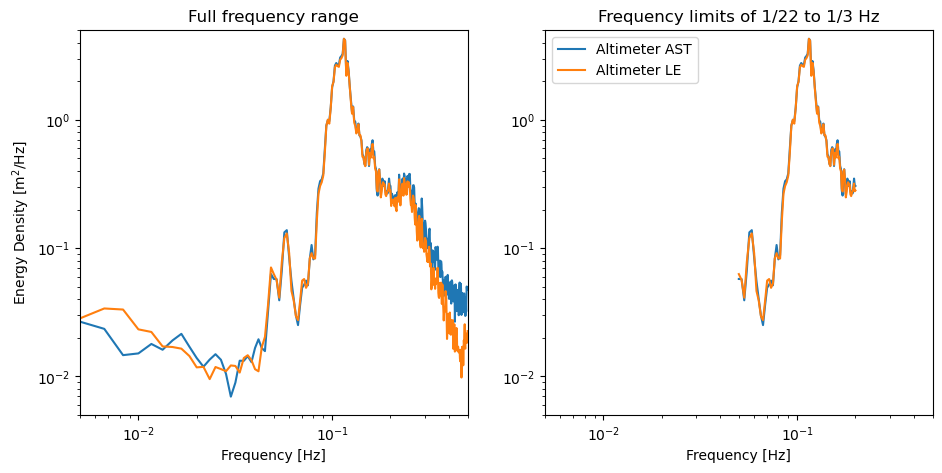

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].loglog(Szz_ast["freq"], Szz_ast.mean("time"), label="Altimeter AST")
ax[0].loglog(Szz_le["freq"], Szz_le.mean("time"), label="Altimeter LE")
ax[0].set(xlabel="Frequency [Hz]", ylabel="Energy Density [m$^2$/Hz]", title ="Full frequency range", xlim=(5e-3, 0.5), ylim=(5e-3, 5))
ax[1].loglog(Szz_ast["freq"].sel(freq=slc_freq), Szz_ast.sel(freq=slc_freq).mean("time"), label="Altimeter AST")
ax[1].loglog(Szz_le["freq"].sel(freq=slc_freq), Szz_le.sel(freq=slc_freq).mean("time"), label="Altimeter LE")
ax[1].set(xlabel="Frequency [Hz]", title="Frequency limits of 1/22 to 1/3 Hz", xlim=(5e-3, 0.5), ylim=(5e-3, 5))
ax[1].legend()

### 4. Compute Basic Wave Statistics

To calculate some basic wave statistics, like significant wave height and peak wave period, we will use functions from the MHKiT Wave module.

In [11]:

# Select frequency range for wave calculations
Szz_ast = Szz_ast.sel(freq=slc_freq)
Szz_le = Szz_le.sel(freq=slc_freq)

# Convert to pandas DataFrame for MHKiT wave resource functions
Szz_ast = Szz_ast.T.to_pandas()
# Calculate wave parameters
Hs_ast = wave.resource.significant_wave_height(Szz_ast)
Tm_ast = wave.resource.average_wave_period(Szz_ast)
Tp_ast = wave.resource.peak_period(Szz_ast)

Szz_le = Szz_le.T.to_pandas()
Hs_le = wave.resource.significant_wave_height(Szz_le)
Tm_le = wave.resource.average_wave_period(Szz_le)
Tp_le = wave.resource.peak_period(Szz_le)

Next we'll create create a bin-averaged dataset using DOLfYN's tools to save these stats in.

In [12]:
# Create averaged dataset
ds_waves_avg = fft_tool.bin_average(ds_waves)
# Convert wave parameters to xarray and add to averaged dataset
ds_waves_avg["wave_height_ast"] = Hs_ast.to_xarray().astype("float32")
ds_waves_avg["mean_period_ast"] = Tm_ast.to_xarray().astype("float32")
ds_waves_avg["peak_period_ast"] = Tp_ast.to_xarray().astype("float32")

ds_waves_avg["wave_height_le"] = Hs_le.to_xarray().astype("float32")
ds_waves_avg["mean_period_le"] = Tm_le.to_xarray().astype("float32")
ds_waves_avg["peak_period_le"] = Tp_le.to_xarray().astype("float32")


And plot. We can see a significant wave height between 1-2 m, mean wave period around 3 s, and a peak period around 9 s. There are some small differences between wave height and period below due to small differences between the AST and LE spectra. Both methods have the same spectral peak, so the peak period is equivalent. Again, the LE method determines the surface as the rising edge of the return acoustic signal, while AST determines the surface as the maximum point of the return acoustic signal.

[Text(0, 0.5, 'Peak Period [s]'), Text(0.5, 0, 'Time')]

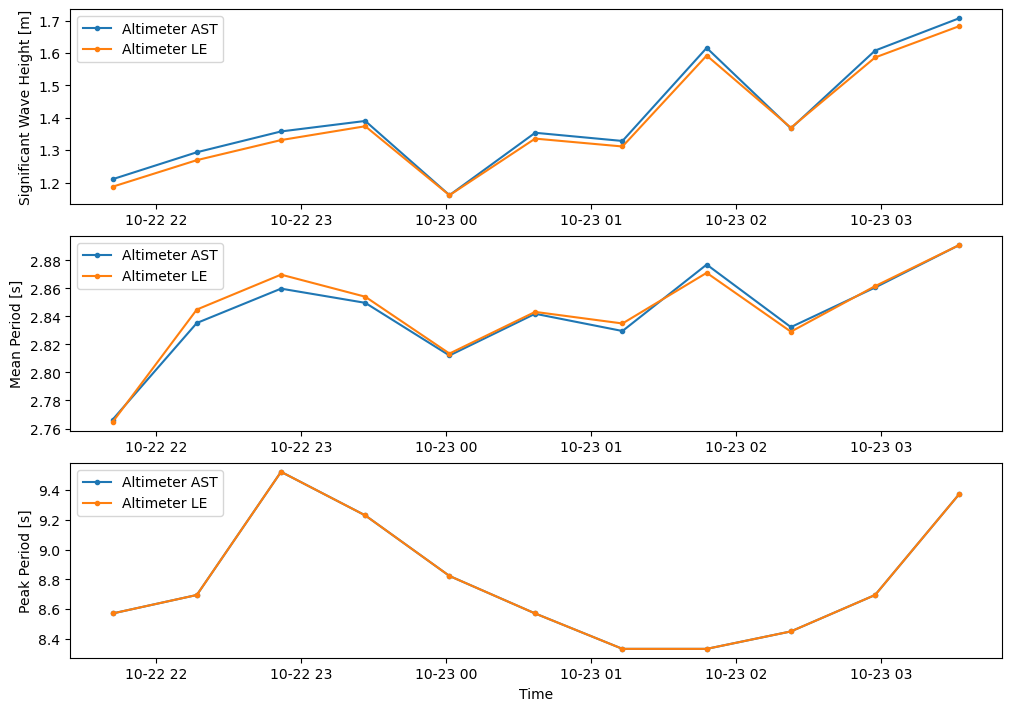

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(10, 7), constrained_layout=True)
ax[0].plot(
    ds_waves_avg["time"],
    ds_waves_avg["wave_height_ast"],
    ".-",
    label="Altimeter AST",
)
ax[0].plot(
    ds_waves_avg["time"],
    ds_waves_avg["wave_height_le"],
    ".-",
    label="Altimeter LE",
)
ax[0].legend()
ax[0].set(ylabel="Significant Wave Height [m]")

ax[1].plot(
    ds_waves_avg["time"],
    ds_waves_avg["mean_period_ast"],
    ".-",
    label="Altimeter AST",
)
ax[1].plot(
    ds_waves_avg["time"],
    ds_waves_avg["mean_period_le"],
    ".-",
    label="Altimeter LE",
)
ax[1].legend()
ax[1].set(ylabel="Mean Period [s]")
ax[2].plot(
    ds_waves_avg["time"],
    ds_waves_avg["peak_period_ast"],
    ".-",
    label="Altimeter AST",
)
ax[2].plot(
    ds_waves_avg["time"],
    ds_waves_avg["peak_period_le"],
    ".-",
    label="Altimeter LE",
)
ax[2].legend()
ax[2].set(ylabel="Peak Period [s]", xlabel="Time")


### 5. Review and QC Surface Velocity Measurements

ADCPs can be used to measure directional wave statistics, albeit to a lower degree of accuracy than one can get using a surface buoy. This can be done using the so-called the "SUV" method (short for "Surface" - "U velocity" - "V velocity"), which uses surface height and the horizontal velocity vector to estimate wave orbital speed and direction. 

First, it is useful to see what velocity data the ADCP is measuring while in wave mode. We'll start by doing some basic processing and plot the velocity data.

In [18]:
# The ADCP transducers were measured to be 0.5 m from the feet of the lander
dolfyn.adp.clean.set_range_offset(ds_waves, 0.5)
# Remove surface sidelobe interference and low correlation values
ds_waves = dolfyn.adp.clean.remove_surface_interference(ds_waves)
ds_waves = dolfyn.adp.clean.correlation_filter(ds_waves, thresh=30)
# Correct magnetic declination
dolfyn.set_declination(ds_waves, 14.8, inplace=True)  # 14.8 deg Eastz
dolfyn.rotate2(ds_waves, "earth")

Data is already in the earth coordinate system


C:\Users\mcve343\MHKiT-Python\mhkit\dolfyn\adp\clean.py:90: UserWarning: The 'range_offset' is either already known or can be calculated from 'bin1_dist_m': 0.5 m. If you would like to override this value with 0.5 m, ignore this warning. If you do not want to override this value, you do not need to use this function.
  warnings.warn(


In the plot below, one can see that the ADCP is only measuring the top half of the water column. In order to measure wave direction, the ADCP needs to be able to capture the wave orbital velocity created by the waves. Because we still need to remove depth bins at the surface that are corrupted by sidelobe interference, the ADCP will generally only be able to measure the direction of long-period gravity waves (i.e., the "peak" or "dominant" wave direction).

C:\Users\mcve343\AppData\Local\Temp\ipykernel_5016\212097317.py:10: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  fig.colorbar(h1, ax=ax[0], label=label, fraction=0.05, pad=0.02)
C:\Users\mcve343\AppData\Local\Temp\ipykernel_5016\212097317.py:21: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  fig.colorbar(h2, ax=ax[1], label=label, fraction=0.05, pad=0.02)


[Text(0.5, 0, 'Time'), Text(0, 0.5, 'Depth [m]'), (0.0, 78.0)]

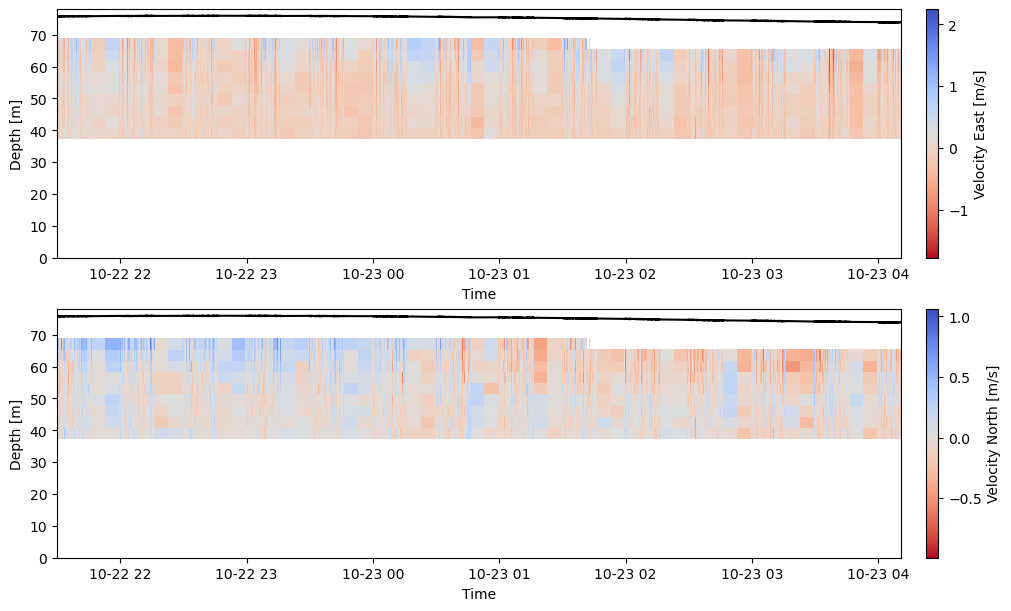

In [15]:
fig, ax = plt.subplots(2, figsize=(10, 6), constrained_layout=True)
h1 = ax[0].pcolor(
    ds_waves["time"].values,
    ds_waves["range"].values,
    ds_waves["vel"][0],
    cmap="coolwarm_r",
)
ax[0].plot(ds_waves["time"], ds_waves["depth"], "k-")
label = "Velocity East [m/s]"
fig.colorbar(h1, ax=ax[0], label=label, fraction=0.05, pad=0.02)
ax[0].set(xlabel="Time", ylabel="Depth [m]", ylim=(0, 78))

h2 = ax[1].pcolor(
    ds_waves["time"].values,
    ds_waves["range"].values,
    ds_waves["vel"][1],
    cmap="coolwarm_r",
)
ax[1].plot(ds_waves["time"], ds_waves["depth"], "k-")
label = "Velocity North [m/s]"
fig.colorbar(h2, ax=ax[1], label=label, fraction=0.05, pad=0.02)
ax[1].set(xlabel="Time", ylabel="Depth [m]", ylim=(0, 78))


### 6. Compute Directional Wave Statistics

The following codeblock runs through the computational steps to estimate peak wave direction and spread. We start by creating a 3x matrix with the highest depth bin for the east and north velocity vectors, plus the surface vector. We next calculate the auto-spectra of each of those vectors, along with their cross-spectra. The auto- and cross-spectra are used to then compute the Fourier coefficients (a1, b1, a2, b2), which define the peak wave direction and spread.

To follow this process using DOLfYN's tools, we'll need to use the `cross_spectral_density` function, which is located in the ADV's API.


In [ ]:
import xarray as xr

## "SUV" method - AST, u velocity, v velocity
fft_tool = dolfyn.adv.api.ADVBinner(
    n_bin=window * ds_waves.fs, fs=ds_waves.fs, n_fft=ds_waves.fs * window // 2
)
# Create 2D tensor for spectral analysis
disp = xr.DataArray(
    data=np.array(
        [
            ds_waves["vel"][0, 7].values,  # first bin continuously below water surface
            ds_waves["vel"][1, 7].values,
            ds_waves["ast_dist_alt"].values,
        ]
    ),
    coords={"dir": ["u", "v", "z"], "time": ds_waves["time"]},
)
# Auto-spectra
psd = fft_tool.power_spectral_density(disp, freq_units="Hz")
psd = psd.sel(freq=slc_freq)
Sxx = psd.sel(S="Sxx")
Syy = psd.sel(S="Syy")
Szz = psd.sel(S="Szz")

# Cross-spectra
csd = fft_tool.cross_spectral_density(disp, freq_units="Hz")
csd = csd.sel(coh_freq=slc_freq)
Cxz = csd.sel(C="Cxz").real
Cxy = csd.sel(C="Cxy").real
Cyz = csd.sel(C="Cyz").real

# Calculate peak wave direction and spread
a1 = Cxz.values / np.sqrt((Sxx + Syy) * Szz)
b1 = Cyz.values / np.sqrt((Sxx + Syy) * Szz)
a2 = (Sxx - Syy) / (Sxx + Syy)
b2 = 2 * Cxy.values / (Sxx + Syy)
theta = np.rad2deg(np.arctan2(b1, a1))  # degrees CCW from East, "to" convention
phi = np.rad2deg(np.sqrt(2 * (1 - np.sqrt(a1**2 + b1**2))))

# Get peak frequency - fill nan slices with 0
peak_idx = Szz.fillna(0).argmax("freq")
# degrees CW from North ("from" convention)
direction = (270 - theta[:, peak_idx]) % 360
# Set direction from -180 to 180
direction[direction > 180] -= 360
spread = phi[:, peak_idx]

ds_waves_avg["wave_a1_value"] = a1
ds_waves_avg["wave_b1_value"] = b1
ds_waves_avg["wave_a2_value"] = a2
ds_waves_avg["wave_b2_value"] = b2
ds_waves_avg["peak_wave_direction"] = direction
ds_waves_avg["peak_wave_spread"] = spread

And plot. Some datapoints may be missing for velocity data that was quality controlled out, but we can see that the highest energy waves are coming from -80 degees (10 degrees north of due West), with a spread of approximately 20 degrees.

[Text(0, 0.5, 'Peak Wave Spread [deg]')]

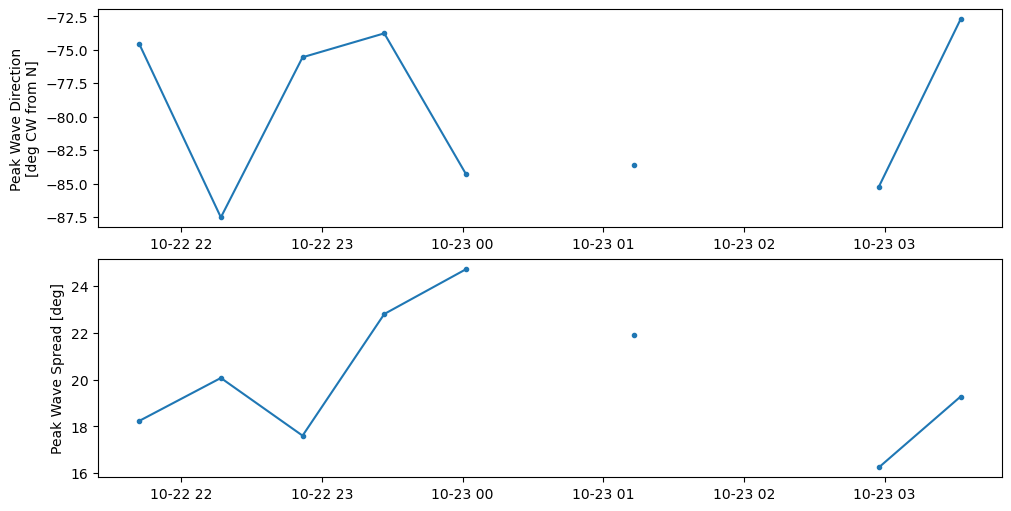

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), constrained_layout=True)
ax[0].plot(
    ds_waves_avg["time"],
    ds_waves_avg["peak_wave_direction"],
    ".-",
)
ax[0].set(ylabel="Peak Wave Direction\n[deg CW from N]")

ax[1].plot(
    ds_waves_avg["time"],
    ds_waves_avg["peak_wave_spread"],
    ".-",
)
ax[1].set(ylabel="Peak Wave Spread [deg]")